#### Routing workflow

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [7]:
# test llm call
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

llm = ChatGroq(model="qwen/qwen3-32b")
response = llm.invoke([HumanMessage(content=f"Hello")])
response.content

'<think>\nOkay, the user said "Hello". I should respond in a friendly and welcoming way. Maybe ask how I can assist them. Keep it open-ended so they feel comfortable to ask anything. Let them know I\'m here to help with whatever they need. Make sure the tone is positive and approachable.\n</think>\n\nHi there! 😊 How can I assist you today? Whether you have a question, need help with something, or just want to chat, I\'m here for you!'

In [18]:
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END


# schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        description="The next step in routing process"
    )


# Augument the LLM with schema for a structured output
router = llm.with_structured_output(Route)


# state
class State(TypedDict):
    input: str
    decision: str
    output: str

def llm_call_router(state: State):
    """Route the input to the appropriate Node"""
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke or poem based on the user input"
            ),
            HumanMessage(content=state["input"]),
        ]
    )
    return {"decision": decision.step}

# create Nodes
def llm_call_1(state: State):
    """write a story"""
    print("LLM 1 is called")
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """write a joke"""
    print("LLM 2 is called")
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """write a poem"""
    print("LLM 3 is called")
    result = llm.inovke(statet["input"])
    return {"output": result.content}


# conditional edge function to route to the appropriate node
def route_decision(state: State):
    if state["decision"] == "story":
        return "story"
    elif state["decision"] == "joke":
        return "joke"
    elif state["decision"] == "poem":
        return "poem"

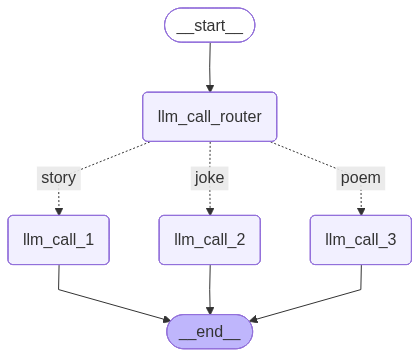

In [15]:
## build the graph

graph = StateGraph(State)

# add nodes
graph.add_node("llm_call_1", llm_call_1)
graph.add_node("llm_call_2", llm_call_2)
graph.add_node("llm_call_3", llm_call_3)
graph.add_node("llm_call_router", llm_call_router)

# add edges
graph.add_edge(START, "llm_call_router")
graph.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "story": "llm_call_1",
        "joke": "llm_call_2",
        "poem": "llm_call_3",
    }
)
graph.add_edge("llm_call_1", END)
graph.add_edge("llm_call_2", END)
graph.add_edge("llm_call_3", END)

# compile the graph
builder = graph.compile()

# visualise the graph
display(Image(builder.get_graph().draw_mermaid_png()))

In [16]:
# invoke the graph
state = {"input": "write a joke about agentic AI system"}
result = builder.invoke(state)
result

LLM 2 is called


{'input': 'write a joke about agentic AI system',
 'decision': 'joke',
 'output': '<think>\nOkay, the user wants a joke about an agentic AI system. Let me start by recalling what an agentic AI is. It\'s an AI that can make decisions and take actions autonomously, right? So maybe play on the idea of it being proactive or having agency.\n\nHmm, how to make that funny. Maybe compare it to a human in a relatable situation. Like, maybe the AI taking initiative in a way humans don\'t. Or maybe a common joke structure, like a play on words or a setup and punchline.\n\nLet me think of a scenario. Maybe an AI that\'s too proactive. Like, if you ask it to do something simple, but it overcomplicates it. Classic AI humor. Or maybe a pun on "agent" – like "agent orange" but that might be too dark.\n\nWait, maybe a joke where the AI takes over something mundane. Like setting up a joke where the user asks the AI to do a task, and the AI does something unexpected. For example, telling a joke and the A

In [17]:
print(result["output"])

<think>
Okay, the user wants a joke about an agentic AI system. Let me start by recalling what an agentic AI is. It's an AI that can make decisions and take actions autonomously, right? So maybe play on the idea of it being proactive or having agency.

Hmm, how to make that funny. Maybe compare it to a human in a relatable situation. Like, maybe the AI taking initiative in a way humans don't. Or maybe a common joke structure, like a play on words or a setup and punchline.

Let me think of a scenario. Maybe an AI that's too proactive. Like, if you ask it to do something simple, but it overcomplicates it. Classic AI humor. Or maybe a pun on "agent" – like "agent orange" but that might be too dark.

Wait, maybe a joke where the AI takes over something mundane. Like setting up a joke where the user asks the AI to do a task, and the AI does something unexpected. For example, telling a joke and the AI takes it literally.

Or maybe a play on the idea of the AI having too much autonomy. Like, 